In [1]:
from IPython.display import Markdown as md
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

from vllm import LLM, SamplingParams

INFO 11-23 11:11:31 [__init__.py:216] Automatically detected platform cuda.


In [2]:
root_path = "/home/stefan/ioai-prep/kits/rezi"

seed = 42

# LLM Inference

In [3]:
llm = LLM(
    model="openai/gpt-oss-20b",
    gpu_memory_utilization=0.9,
    max_model_len=4096,
    max_num_seqs=16,
)

INFO 11-23 11:11:35 [utils.py:233] non-default args: {'max_model_len': 4096, 'max_num_seqs': 16, 'disable_log_stats': True, 'model': 'openai/gpt-oss-20b'}
INFO 11-23 11:11:36 [model.py:547] Resolved architecture: GptOssForCausalLM


`torch_dtype` is deprecated! Use `dtype` instead!


Parse safetensors files:   0%|          | 0/3 [00:00<?, ?it/s]

INFO 11-23 11:11:37 [model.py:1510] Using max model len 4096
INFO 11-23 11:11:39 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 11-23 11:11:39 [config.py:271] Overriding max cuda graph capture size to 992 for performance.
(EngineCore_DP0 pid=32372) INFO 11-23 11:11:41 [core.py:644] Waiting for init message from front-end.
(EngineCore_DP0 pid=32372) INFO 11-23 11:11:41 [core.py:77] Initializing a V1 LLM engine (v0.11.0) with config: model='openai/gpt-oss-20b', speculative_config=None, tokenizer='openai/gpt-oss-20b', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=mxfp4, enforce_eager=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto'

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


(EngineCore_DP0 pid=32372) INFO 11-23 11:11:47 [default_loader.py:267] Loading weights took 3.11 seconds
(EngineCore_DP0 pid=32372) WARNING 11-23 11:11:47 [marlin_utils_fp4.py:196] Your GPU does not have native support for FP4 computation but FP4 quantization is being used. Weight-only FP4 compression will be used leveraging the Marlin kernel. This may degrade performance for compute-heavy workloads.
(EngineCore_DP0 pid=32372) INFO 11-23 11:11:48 [gpu_model_runner.py:2653] Model loading took 13.7164 GiB and 5.013254 seconds
(EngineCore_DP0 pid=32372) INFO 11-23 11:11:52 [backends.py:548] Using cache directory: /home/stefan/.cache/vllm/torch_compile_cache/5ef53a98b7/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=32372) INFO 11-23 11:11:52 [backends.py:559] Dynamo bytecode transform time: 4.23 s
(EngineCore_DP0 pid=32372) INFO 11-23 11:11:55 [backends.py:197] Cache the graph for dynamic shape for later use
(EngineCore_DP0 pid=32372) INFO 11-23 11:12:19 [backends.py:218] C

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 81/81 [00:06<00:00, 12.04it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 5/5 [00:04<00:00,  1.23it/s]


(EngineCore_DP0 pid=32372) INFO 11-23 11:12:35 [gpu_model_runner.py:3480] Graph capturing finished in 12 secs, took 0.69 GiB
(EngineCore_DP0 pid=32372) INFO 11-23 11:12:35 [core.py:210] init engine (profile, create kv cache, warmup model) took 46.92 seconds
INFO 11-23 11:12:37 [llm.py:306] Supported_tasks: ['generate']


# Data

In [4]:
test_df = pd.read_csv(f"{root_path}/test.csv")
test_df.head()

,SampleID,Question,Option0,Option1,Option2,Option3
0,b64a9cd7-d076-4c55-8be1-f9c44fece6cc,A 29 yrs old woman with a pregnancy of 17 week...,No test is required now as her age is below 35...,Ultra sound at this point of time will definit...,Amniotic fluid samples plus chromosomal analys...,blood screening at this point of time will cle...
1,17360c6c-2c98-4fe2-aa85-487dcf4678df,Concentration of tropicamide:,0.01,0.02,0.03,0.04
2,ce49098b-cc48-4168-859e-936e3e0c7459,Which of the following are not a branch of ext...,Sphenopalatine aery,Anterior ethmoidal aery,Greater palatine aery,Septal branch of superior labial aery
3,18d5c4a1-cb81-41a8-9bfc-b6f7dec431d2,Diagnosis of the following ECG-,Ventricular bigeminy,Electrical alternans,P pulmonale,Left ventricular failure
4,384a9281-2ee1-480b-a7d8-fd3ef49558e5,27.\tThe lateral spread of dental caries is fa...,Enamel spindles,Dentinoenamel junction,Enamel lamellae,Striae of Retzius


In [ ]:
def build_prompt(row):
    prompt = f"""You are given the following Question, from a Medical University exam:
```
{row["Question"]}
```

You have to answer from the following answer options:

1. {row["Option0"]}

2. {row["Option1"]}

3. {row["Option2"]}

4. {row["Option3"]}

Respond only with the correct number.
"""
    return prompt

def apply_template(row):
    prompt = llm.get_tokenizer().apply_chat_template(
        conversation=[
            {
                "role": "user",
                "content": row["Prompt"]
                # to disable reasoning:
                #+ "<|end|><|start|>assistant<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>",
            }
        ],
        tokenize=False,
        reasoning_effort="low",
    )
    return prompt

test_df["Prompt"] = test_df.apply(build_prompt, axis=1)
test_df["Convo"] = test_df.apply(apply_template, axis=1)

count    2816.000000
mean      632.529119
std        82.617012
min       500.000000
25%       578.000000
50%       610.000000
75%       665.000000
max      1253.000000
Name: Convo, dtype: float64


<Axes: >

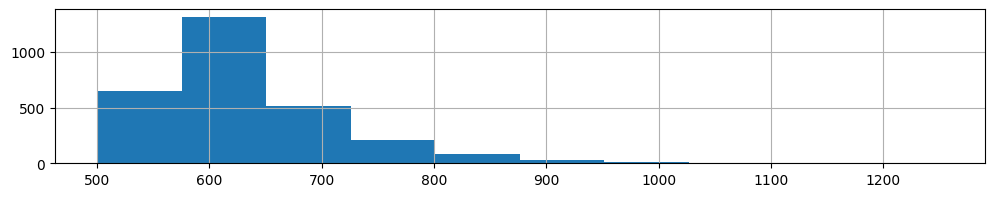

In [76]:
print(test_df["Convo"].apply(len).describe())

plt.figure(figsize=(12, 2))
test_df["Convo"].apply(len).hist()

In [77]:
test_df.iloc[0]["Convo"]

'<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.\nKnowledge cutoff: 2024-06\nCurrent date: 2025-11-23\n\nReasoning: low\n\n# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>You are given the following Question, from a Medical University exam:\n```\nA 29 yrs old woman with a pregnancy of 17 week has a 10 years old boy with down syndrome. She does not want another down syndrome kid; best advice to her is\n```\n\nYou have to answer from the following answer options:\n\n1. No test is required now as her age is below 35 years\n\n2. Ultra sound at this point of time will definitely tell her that next baby will be down syndromic or not\n\n3. Amniotic fluid samples plus chromosomal analysis will definitely tell her that next baby will be down syndromic or not\n\n4. blood screening at this point of time will clear the exact picture\n\nRespond only with the correct number.\n<|end|>'

In [93]:
sample_prompt = test_df.iloc[0]["Convo"]
md(test_df.iloc[0]["Prompt"])

You are given the following Question, from a Medical University exam:
```
A 29 yrs old woman with a pregnancy of 17 week has a 10 years old boy with down syndrome. She does not want another down syndrome kid; best advice to her is
```

You have to answer from the following answer options:

1. No test is required now as her age is below 35 years

2. Ultra sound at this point of time will definitely tell her that next baby will be down syndromic or not

3. Amniotic fluid samples plus chromosomal analysis will definitely tell her that next baby will be down syndromic or not

4. blood screening at this point of time will clear the exact picture

Respond only with the correct number.


# Submission

In [79]:
sampling_params = SamplingParams(temperature=0.8, top_p=0.95, max_tokens=2000)

In [80]:
output = llm.generate(sample_prompt, sampling_params)[0]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [81]:
md(output.outputs[0].text[:-1])

analysisWe need best advice: she's 29, 17 weeks. Has a child with Down. She wants to avoid. Options: 1: no test now age <35. 2: ultrasound will definitely tell. 3: amniocentesis and karyotype will definitely tell. 4: blood screening will clear exact picture.

Best is amniocentesis at 17 weeks gives definitive. So option 3.final

In [ ]:
prompts = test_df["Convo"].tolist()

# generate in batches
outputs = []
for i, out in enumerate(
    tqdm(llm.generate(prompts, sampling_params), total=len(prompts))
):
    outputs.append(out)

Adding requests:   0%|          | 0/2816 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2816 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

100%|██████████| 2816/2816 [00:00<00:00, 1981405.82it/s]


In [88]:
def extract_digit(text: str) -> int:
    ch = text.strip()[-1]
    if ch in {"1", "2", "3", "4"}:
        return int(ch)
    return 5  # fallback


test_df["PredictedAnswer"] = [extract_digit(o.outputs[0].text) for o in outputs]

<Axes: >

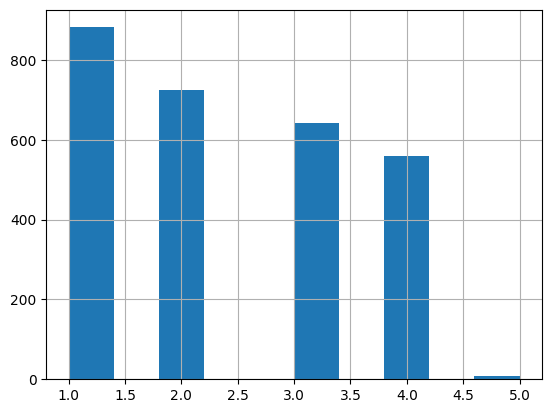

In [89]:
test_df["PredictedAnswer"].hist()

In [90]:
test_df["PredictedAnswer"] = test_df["PredictedAnswer"].replace(5, 2) - 1

In [91]:
submission = test_df[["SampleID", "PredictedAnswer"]].rename(
    columns={"SampleID": "DatapointID"}
)
submission.to_csv(f"{root_path}/submission.csv", index=False)

In [92]:
submission.head()

,DatapointID,PredictedAnswer
0,b64a9cd7-d076-4c55-8be1-f9c44fece6cc,2
1,17360c6c-2c98-4fe2-aa85-487dcf4678df,0
2,ce49098b-cc48-4168-859e-936e3e0c7459,1
3,18d5c4a1-cb81-41a8-9bfc-b6f7dec431d2,1
4,384a9281-2ee1-480b-a7d8-fd3ef49558e5,2
